In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

In [5]:
df =pd.read_csv(r'C:\Users\zbook g6\Desktop\DEBI-ONL4_AIS2_S2\DEBI-ONL4_AIS2_S2\Data\income.csv')

In [6]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income ($)')

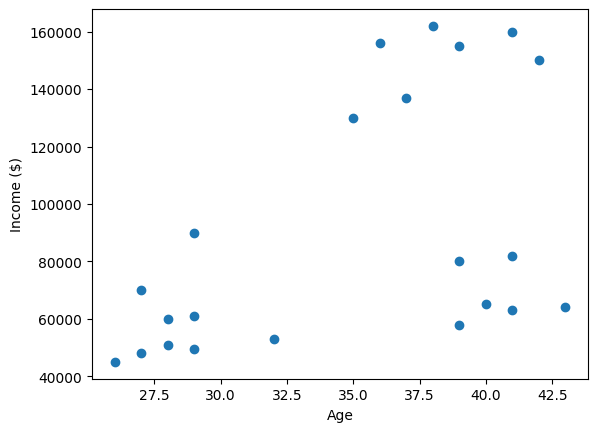

In [9]:
plt.scatter(df.Age, df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income ($)')

In [10]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age' ,'Income($)']])
y_predicted

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
      dtype=int32)

In [11]:
df['Cluster']=y_predicted
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,1
1,Michael,29,90000,2
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


In [12]:
km.cluster_centers_

array([[3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04],
       [3.63333333e+01, 8.40000000e+04]])

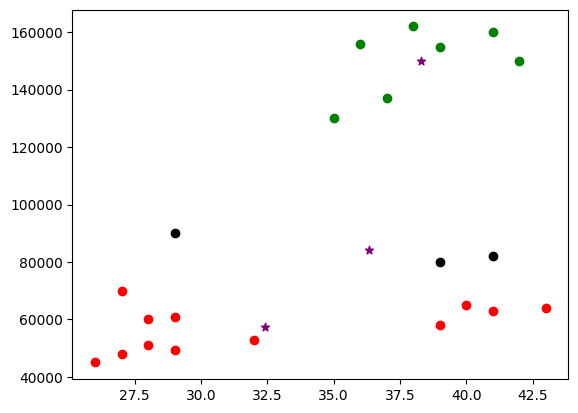

In [15]:
df1=df[df['Cluster']==0]
df2=df[df['Cluster']==1]
df3=df[df['Cluster']==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:, 1], color='purple',marker='*', label='centroid')

In [16]:
scaler = MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']= scaler.transform(df[['Income($)']])
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,0.213675,1
1,Michael,29,0.384615,2
2,Mohan,29,0.136752,1
3,Ismail,28,0.128205,1
4,Kory,42,0.897436,0


In [17]:
df ['Age' ]= scaler. fit_transform(df[ ['Age']])
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [18]:
km1 = KMeans(n_clusters=3)
y_pred_2 = km1. fit_predict(df[['Age','Income($)']])
y_pred_2

array([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [19]:
df['cluster2'] =y_pred_2
df.head()

,Name,Age,Income($),Cluster,cluster2
0,Rob,0.058824,0.213675,1,0
1,Michael,0.176471,0.384615,2,0
2,Mohan,0.176471,0.136752,1,0
3,Ismail,0.117647,0.128205,1,0
4,Kory,0.941176,0.897436,0,2


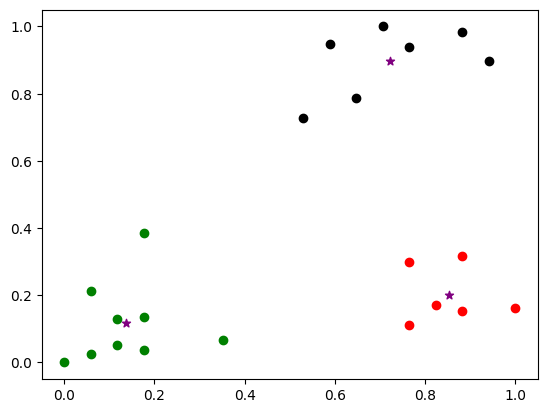

In [22]:
df1=df[df['cluster2']==0]
df2=df[df['cluster2']==1]
df3=df[df['cluster2']==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km1.cluster_centers_[:,0],km1.cluster_centers_[:, 1], color='purple',marker='*', label='centroid')

In [25]:
sse = []
k_range = range(1,10)
for k in k_range:
 km = KMeans(n_clusters=k)
 km.fit(df[['Age','Income($)']])
 sse.append(km.inertia_)


In [26]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.34910470944195654,
 0.28607171066894405,
 0.25123327086052233,
 0.18850242078456825,
 0.1327661931978319,
 0.12823323338694645]

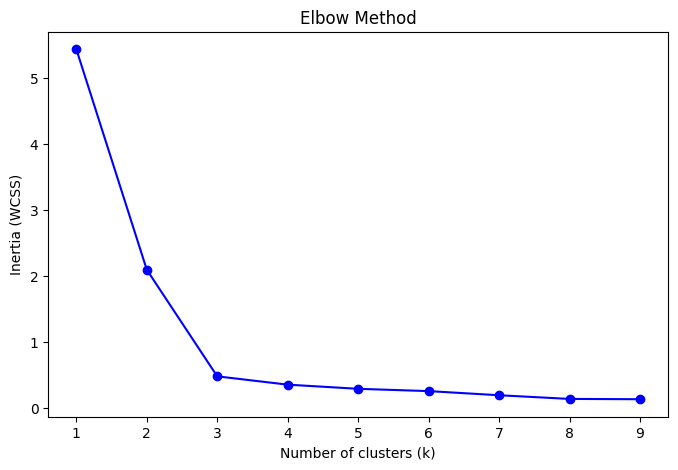

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, sse, 'bo-')  
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()